In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [27]:
#Retrieve data

ticker = "MSFT"
end = dt.datetime.now()
start = end - dt.timedelta(days = 365)
df = yf.download(ticker, start = start, end = end, auto_adjust = False)
df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [28]:
#Create new columns needed for stats

movAvg_win = 50
momentum_win = 25

df['momentum'] = df['Adj Close'].pct_change(momentum_win).fillna(0)
df['ma_50'] = df['Adj Close'].rolling(window = movAvg_win, min_periods = 0).mean()


In [29]:
#Create a buy or sell signal
#The signal puts more weight onto uptrends rather than downtrends, given by
#the return value of 2 vs 1

def give_signal(row):
    threshold = 0.01

    if pd.isna(row['momentum']) or pd.isna(row['Adj Close']) or pd.isna(row['ma_50']):
        return 0
    
    if row['momentum'] > threshold and row['Adj Close'] > row['ma_50']:
        return 1
    elif row['momentum'] < -threshold and row['Adj Close'] < row['ma_50']:
        return -1
    else:
        return 0

df['signal'] = df.apply(give_signal, axis=1)

Benchmark return: 15.24%
Strategy return: 9.60%


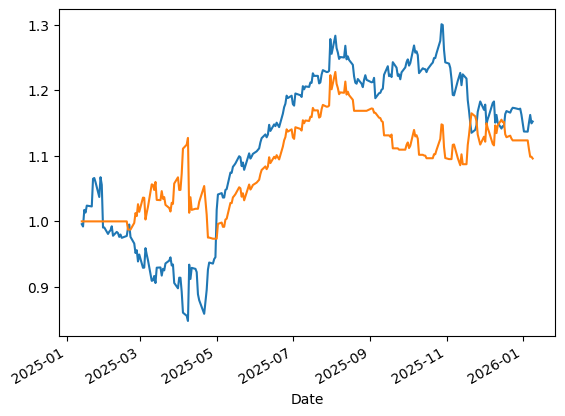

In [30]:
#Calculate returns

returns = df['Adj Close'].pct_change()
strat = df['signal'].shift(1) * returns

benchReturns = (1 + returns).cumprod()
benchReturns.plot()

stratReturns = (1 + strat).cumprod()
stratReturns.plot()

print(f'Benchmark return: {(benchReturns.iloc[-1] - 1) * 100:0.2f}%')
print(f'Strategy return: {(stratReturns.iloc[-1] - 1) * 100:0.2f}%')